In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,layers,losses,Model
from random import randint

In [5]:

(X_train,Y_Train),(X_test,Y_test) = (tf.keras.datasets.mnist.load_data())

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [6]:

noise_factor = 0.4

X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)

X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)

X_test_noisy = np.clip(X_test_noisy, 0., 1.)


In [7]:
# desiging encoder model
input_layer = layers.Input(shape=X_train.shape[1:])
flattened  = layers.Flatten()(input_layer)
hidden = layers.Dense(100,activation='relu')(flattened)
latent  = layers.Dense(20,activation='relu')(hidden)


# encoder
encoder =  Model(
    inputs=input_layer,
    outputs=latent,
    name = 'encoder'
    )

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,520 (314.53 KB)

 Trainable params: 80,520 (314.53 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# designing decoder model

input_layer_decoder = layers.Input(shape=encoder.output.shape[1:])
upsampled = layers.Dense(100 ,activation='relu')(input_layer_decoder)
Upsampled = layers.Dense(784,activation='relu')(upsampled)
constructed_image = layers.Reshape(X_train.shape[1:])(Upsampled)


decoder = Model(
    inputs = input_layer_decoder,
    outputs = constructed_image,
    name = 'decoder'
    )

decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        79,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,284 (317.52 KB)

 Trainable params: 81,284 (317.52 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# designing Auto encoder

autoencoder =  Model(inputs= encoder.input,outputs = decoder(encoder.output) ,name = 'Autoencoder')

autoencoder.summary()
autoencoder.compile(
    optimizer = 'adam',
    loss = losses.MeanSquaredError(),
    metrics = ['accuracy']  
)

history = autoencoder.fit(X_train_noisy,X_train , epochs=5, batch_size = 32 , validation_data = (X_test,X_test))


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28)         │        81,284 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,804 (632.05 KB)

 Trainable params: 161,804 (632.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4288 - loss: 0.0362 - val_accuracy: 0.4710 - val_loss: 0.0299
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4708 - loss: 0.0285 - val_accuracy: 0.4820 - val_loss: 0.0273
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4817 - loss: 0.0266 - val_accuracy: 0.4881 - val_loss: 0.0254
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4861 - loss: 0.0258 - val_accuracy: 0.4915 - val_loss: 0.0251
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4897 - loss: 0.0251 - val_accuracy: 0.4928 - val_loss: 0.0237


Text(0.5, 1.0, 'Accuracy plot')

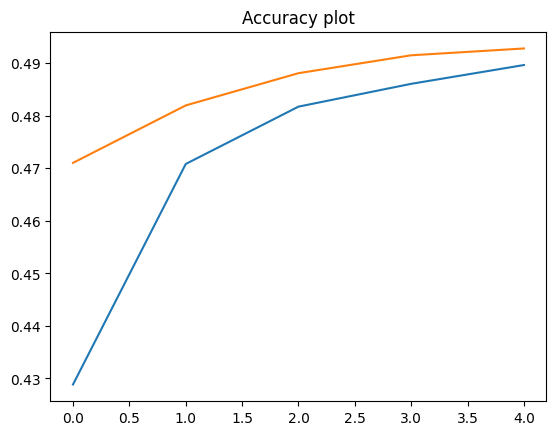

In [10]:
# accuracy and loss plot
plt.plot(history.history['accuracy'],label = 'train accuracy')
plt.plot(history.history['val_accuracy'],label = 'test accuracy')
plt.title('Accuracy plot')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


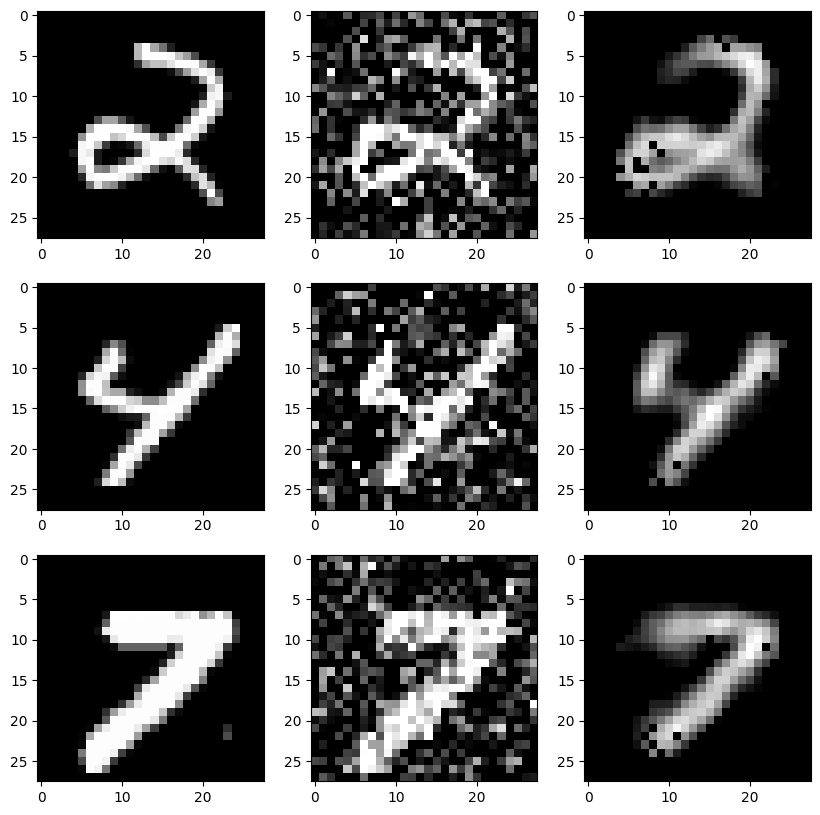

In [19]:
# taking random imagea and checking
fig,axs = plt.subplots(3,3,figsize = (10,10))
for i in range(3):

    idx = randint(0,X_train_noisy.shape[0])
    sample = X_train[idx]
    noisy_sample = X_train_noisy[idx]
    axs[i,0].imshow(sample,cmap='gray')
    axs[i,1].imshow(noisy_sample,cmap='gray')
    axs[i,2].imshow(autoencoder.predict(np.expand_dims(noisy_sample,axis=0))[0],cmap='gray')
plt.show()